In [7]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
# to surpress RuntimeWarnings, ok here when lookin for parameters
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def plot_ppm(
    posterior_probability_matrix: np.ndarray,
    corridor_start: int,
    corridor_end: int,
    temporal_bin_size: int,
    vmin: float = 0,
    vmax: float = None
):
    n_time, n_pos = posterior_probability_matrix.shape
    fig, ax = plt.subplots()
    im = ax.imshow(
        posterior_probability_matrix.T,
        vmin=vmin,
        vmax=vmax if vmax is not None else np.max(posterior_probability_matrix) * 1.1,
        aspect="auto",
    )
    fig.colorbar(im, ax=ax, label="Posterior Probability")
    time_seconds = n_time * temporal_bin_size / 30
    if time_seconds >= 65:
        width = max(10, n_time / 100)
        fig.set_size_inches(width, 6, forward=True)
        ax.set_xlabel("Time (minutes)")
        # for now setting one tick per minute, i.e. every 1800 frames
        xtick_frames = np.arange(0, n_time * temporal_bin_size + 1, 1800)
        xtick_bins = xtick_frames / temporal_bin_size
        xtick_labels = np.round(xtick_frames / (30 * 60), 2)
        ax.set_xticks(xtick_bins)
        ax.set_xticklabels(xtick_labels)
        ax.set_ylabel("Position (centimetres)")
    else:
        width = max(10, n_time / 10)
        fig.set_size_inches(width, 6, forward=True)
        ax.set_xlabel("Time (seconds)")
        if time_seconds >= 3:
            # one tick per second
            xtick_frames = np.arange(0, n_time * temporal_bin_size + 1, 30)
        else:
            # one tick every half second
            xtick_frames = np.arange(0, n_time * temporal_bin_size + 1, 15)
        xtick_bins = xtick_frames / temporal_bin_size
        xtick_labels = np.round(xtick_frames / 30, 2)
        ax.set_xticks(xtick_bins)
        ax.set_xticklabels(xtick_labels)
    ax.set_yticks(
        np.linspace(0, n_pos - 1, 5),
        [
            str(x)
            for x in np.linspace(corridor_start, corridor_end, 5).astype(
                int
            )
        ],
    )
    ax.set_ylim(n_pos - 1, 0)
    fig.show()

In [9]:
SERVER_PATH = Path("/home/josef/mnt/MarcBusche/Josef")

In [10]:
ppm_path_spks = SERVER_PATH / "viral_caches" / "bayesian" / "ppm" / "spks_all"
ppm_path_dff = SERVER_PATH / "viral_caches" / "bayesian" / "ppm" / "dff_all"

In [11]:
corridor_start = 0
corridor_end = 180
temporal_bin_size = 5 # frames, CAUTION: has to match the bin size used for decoding (bin_size_time_offline)

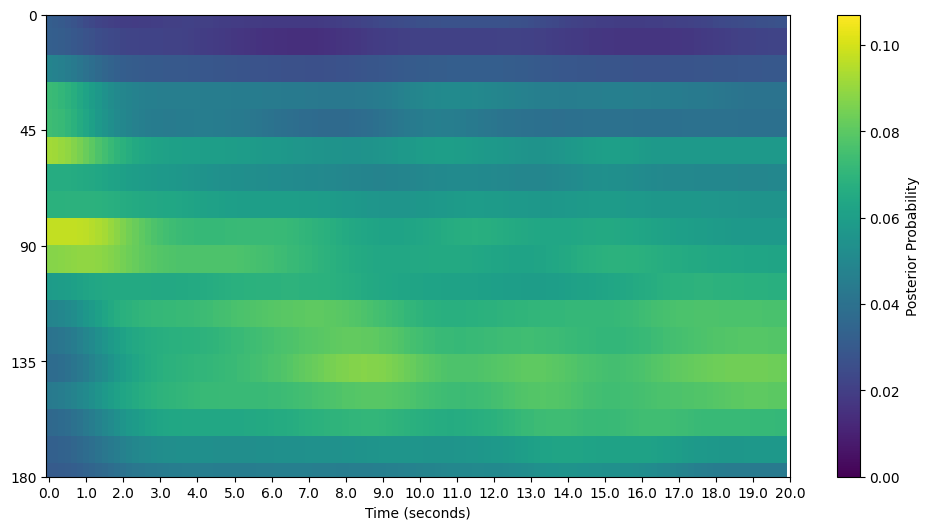

In [12]:
chunk_path = ppm_path_spks / "JB014_2024-11-04_ppm)_trial19_chunk1.npy"
plot_ppm(corridor_start=corridor_start, corridor_end=corridor_end, posterior_probability_matrix=np.load(chunk_path), temporal_bin_size=temporal_bin_size)

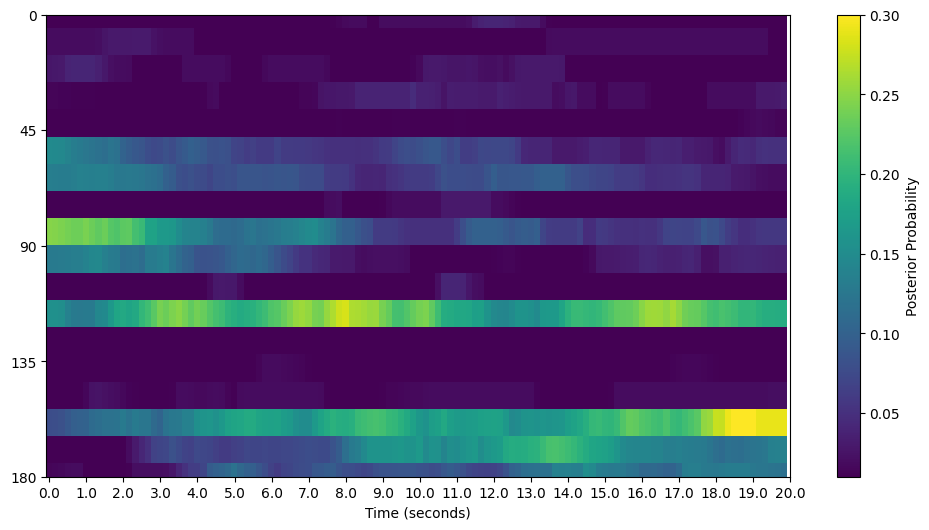

In [13]:
chunk_path = ppm_path_dff / "JB014_2024-11-04_ppm)_trial19_chunk1.npy"
plot_ppm(corridor_start=corridor_start, corridor_end=corridor_end, posterior_probability_matrix=np.load(chunk_path), temporal_bin_size=temporal_bin_size, vmin=0.01, vmax=0.30)

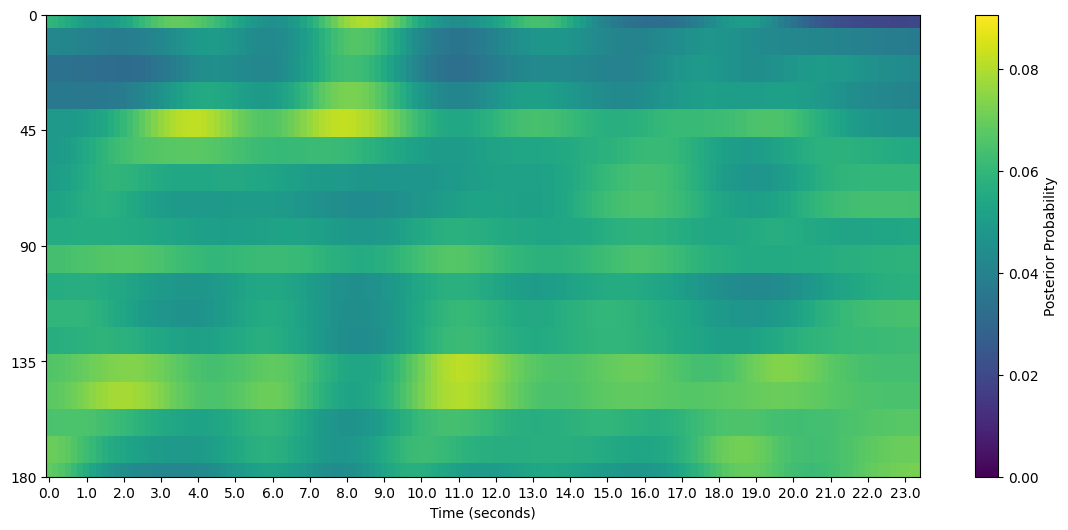

In [14]:
chunk_path = ppm_path_spks / "JB034_2025-07-04_ppm)_trial0_chunk0.npy"
plot_ppm(posterior_probability_matrix=np.load(chunk_path), corridor_start=corridor_start, corridor_end=corridor_end, temporal_bin_size=temporal_bin_size)

In [ ]:
chunk_path = ppm_path_dff / "JB034_2025-07-04_ppm)_trial0_chunk0.npy"
plot_ppm(posterior_probability_matrix=np.load(chunk_path), corridor_start=corridor_start, corridor_end=corridor_end, temporal_bin_size=temporal_bin_size, vmin=0.03, vmax=0.20)

FileNotFoundError: [Errno 2] No such file or directory: '/home/josef/mnt/MarcBusche/Josef/viral_caches/bayesian/ppm/dff_all/JB034_2025-07-04_trial0_chunk0_ppm.npy'

In [ ]:
chunk_path = ppm_path_spks / "JB019_2024-11-20_ppm)_trial5_chunk1.npy"
plot_ppm(posterior_probability_matrix=np.load(chunk_path), corridor_start=corridor_start, corridor_end=corridor_end, temporal_bin_size=temporal_bin_size)

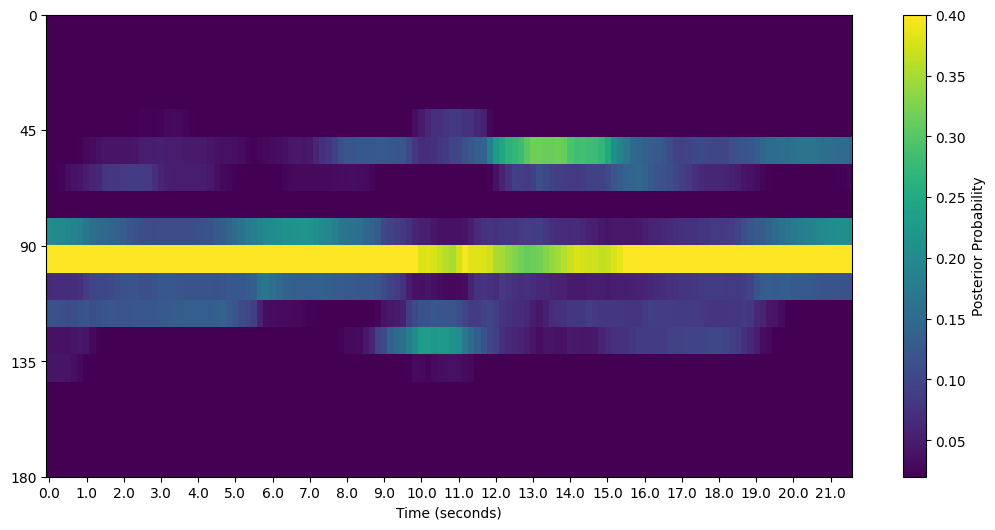

In [ ]:
chunk_path = ppm_path_dff / "JB019_2024-11-20_ppm)_trial5_chunk1.npy"
plot_ppm(posterior_probability_matrix=np.load(chunk_path), corridor_start=corridor_start, corridor_end=corridor_end, temporal_bin_size=temporal_bin_size, vmin=0.02, vmax=0.4)